In [5]:
import numpy as np
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def black_scholes(S:np.float32, 
                  T:np.float32, 
                  r:np.float32, 
                  K:np.float32, 
                  sigma:np.float32, 
                  option_type:str='call') -> np.float64:
    d1 = (np.log(S/K) + (r + (sigma**2 / 2))*T) / sigma*np.sqrt(T)
    d2 = d1 - sigma*T**0.5
    if option_type == 'call':
            return (S*norm.cdf(d1) 
            - np.exp(-r*T)*K*norm.cdf(d2))
    elif option_type == 'put':
        return (np.exp(-r*T)*K*norm.cdf(-d2)
        - S*norm.cdf(-d1))


In [7]:
print(type(black_scholes(100, 1, 0.05, 100, 0.2, 'call')))
print(black_scholes(100, 1, 0.05, 100, 0.2, 'put'))

<class 'numpy.float64'>
5.573526022256971


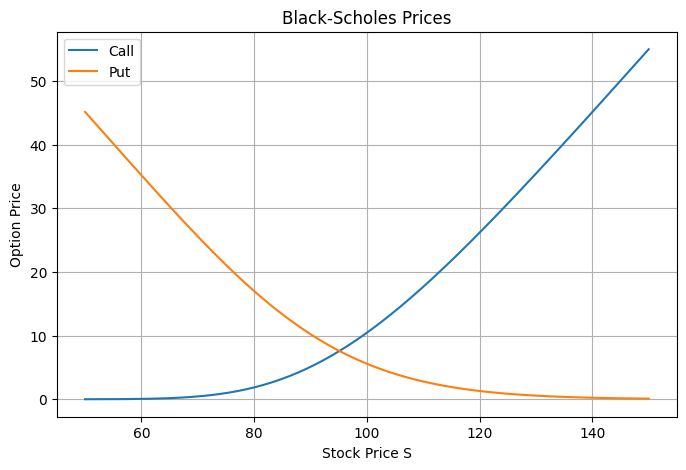

In [8]:
S_vals = np.linspace(50, 150, 200)

call_prices = [
    black_scholes(S, 1, 0.05, 100, 0.2, 'call')
    for S in S_vals
]

put_prices = [
    black_scholes(S, 1, 0.05, 100, 0.2, 'put')
    for S in S_vals
]

plt.figure(figsize=(8,5))
plt.plot(S_vals, call_prices, label='Call')
plt.plot(S_vals, put_prices, label='Put')

plt.xlabel('Stock Price S')
plt.ylabel('Option Price')
plt.title('Black-Scholes Prices')
plt.legend()
plt.grid(True)

plt.show()

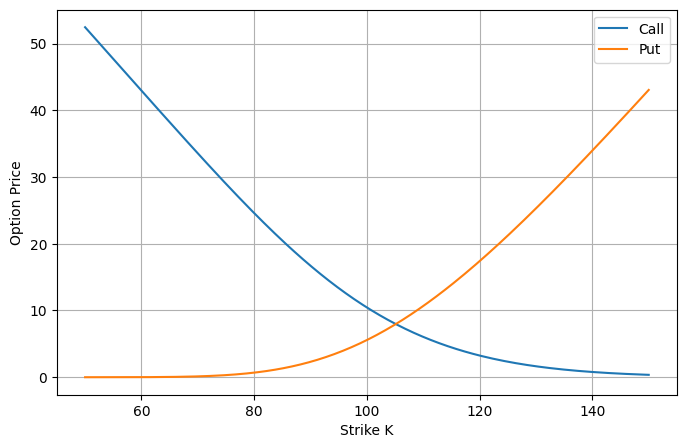

In [9]:
K_vals = np.linspace(50,150,200)

call_prices = [
    black_scholes(100, 1, 0.05, K, 0.2, 'call')
    for K in K_vals
]

put_prices = [
    black_scholes(100, 1, 0.05, K, 0.2, 'put')
    for K in K_vals
]

plt.figure(figsize=(8,5))
plt.plot(K_vals, call_prices, label='Call')
plt.plot(K_vals, put_prices, label='Put')

plt.xlabel('Strike K')
plt.ylabel('Option Price')
plt.legend()
plt.grid()
plt.show()

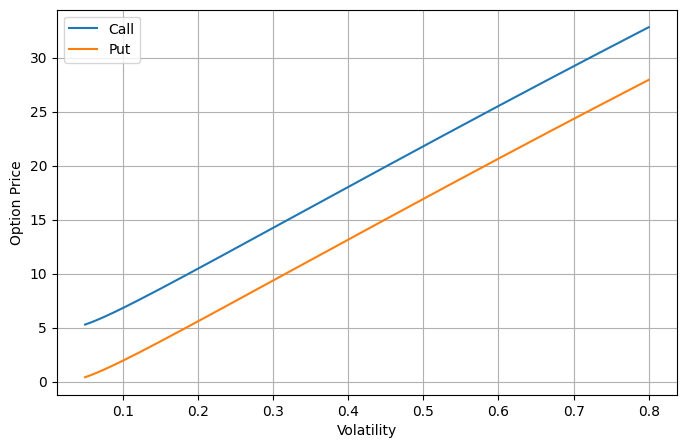

In [10]:
sigmas = np.linspace(0.05, 0.8, 200)

call_prices = [
    black_scholes(100, 1, 0.05, 100, sigma, 'call')
    for sigma in sigmas
]

put_prices = [
    black_scholes(100, 1, 0.05, 100, sigma, 'put')
    for sigma in sigmas
]

plt.figure(figsize=(8,5))
plt.plot(sigmas, call_prices, label='Call')
plt.plot(sigmas, put_prices, label='Put')

plt.xlabel('Volatility')
plt.ylabel('Option Price')
plt.legend()
plt.grid()
plt.show()